In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    cohen_kappa_score,
    top_k_accuracy_score
)

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_validate
import numpy as np

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("C:/Users/dhars/Downloads/Maths project/data/career_recommendation_synthetic.csv")



In [2]:
# ===============================
# MULTI-VALUE FEATURES
# ===============================
for col in ["skills", "interests", "certifications"]:
    df[col] = df[col].apply(lambda x: x.split(","))

mlb = MultiLabelBinarizer()
skill_features = mlb.fit_transform(
    df["skills"] + df["interests"] + df["certifications"]
)
skill_df = pd.DataFrame(skill_features, columns=mlb.classes_)

# ===============================
# ENCODE CATEGORICAL FEATURES
# ===============================
le_course = LabelEncoder()
le_spec = LabelEncoder()

df["ug_course"] = le_course.fit_transform(df["ug_course"])
df["ug_specialization"] = le_spec.fit_transform(df["ug_specialization"])

# ===============================
# SCALE NUMERIC FEATURES
# ===============================
scaler = StandardScaler()
df["cgpa"] = scaler.fit_transform(df[["cgpa"]])

# ===============================
# TARGET ENCODING
# ===============================
le_target = LabelEncoder()
y = le_target.fit_transform(df["career_domain"])



In [3]:
# ===============================
# FEATURE MATRIX
# ===============================
X = df.drop(columns=["career_domain", "skills", "interests", "certifications"])
X = pd.concat([X.reset_index(drop=True), skill_df], axis=1)

# ===============================
# TRAIN / VALIDATION / TEST SPLIT
# ===============================
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")



Training set size: 640
Validation set size: 160
Test set size: 200



In [4]:
# ===============================
# MODEL definition and TRAINING
# # ===============================
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le_target.classes_),
    n_estimators=100,  
    max_depth=2,  
    learning_rate=0.01,  
    subsample=0.6,  
    colsample_bytree=0.6,  
    colsample_bylevel=0.6,  
    reg_alpha=7.0,  
    reg_lambda=7.0,  
    min_child_weight=5.01,  
    gamma=3.0,  
    eval_metric="mlogloss",
    random_state=42,
    early_stopping_rounds=10,
    verbosity=0
)

# Train with early stopping on validation set
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.6, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=3.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=5.01, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=10, ...)

In [5]:
# ===============================
# PREDICTIONS
# ===============================
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ===============================
# OVERFITTING DIAGNOSTICS
# ===============================
train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred)

print("\n===== OVERFITTING DIAGNOSTICS =====")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

if train_acc > val_acc + 0.05:
    print("⚠️  WARNING: Training accuracy much higher than validation - possible overfitting!")
else:
    print("✓ No significant overfitting detected")




===== OVERFITTING DIAGNOSTICS =====
Training Accuracy: 0.9984
Validation Accuracy: 0.9938
Test Accuracy: 0.9950
✓ No significant overfitting detected



===== BASIC METRICS =====
Accuracy: 0.995

Classification Report:

                           precision    recall  f1-score   support

                  AI / ML       1.00      1.00      1.00        21
       Business / Finance       1.00      1.00      1.00        18
           Cloud / DevOps       1.00      1.00      1.00        20
         Core Engineering       1.00      1.00      1.00        21
            Cybersecurity       1.00      1.00      1.00        19
             Data Science       1.00      0.94      0.97        17
         Management / MBA       1.00      1.00      1.00        19
Research / Higher Studies       1.00      1.00      1.00        22
     Software Engineering       1.00      1.00      1.00        22
          Web Development       0.95      1.00      0.98        21

                 accuracy                           0.99       200
                macro avg       1.00      0.99      0.99       200
             weighted avg       1.00      0.99      0.99   

<Figure size 1000x800 with 0 Axes>

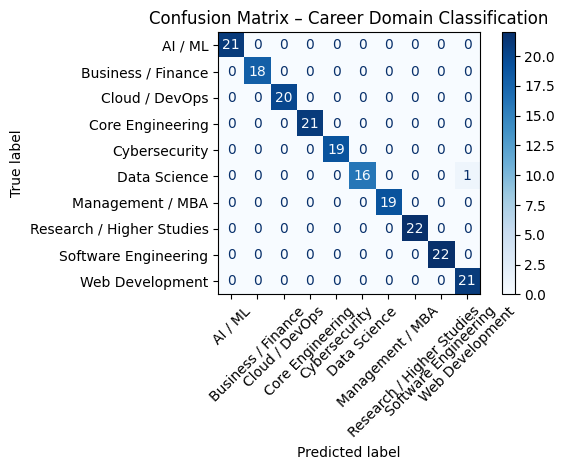

In [6]:
# ===============================
# BASIC METRICS
# ===============================
print("\n===== BASIC METRICS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_target.classes_
)

plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Career Domain Classification")
plt.tight_layout()
plt.show()



In [7]:
# ===============================
# PRECISION / RECALL / F1
# ===============================
print("\n===== PRECISION / RECALL / F1 =====")
print("Macro Precision :", precision_score(y_test, y_pred, average="macro"))
print("Macro Recall    :", recall_score(y_test, y_pred, average="macro"))
print("Macro F1 Score  :", f1_score(y_test, y_pred, average="macro"))

print("\nWeighted Precision :", precision_score(y_test, y_pred, average="weighted"))
print("Weighted Recall    :", recall_score(y_test, y_pred, average="weighted"))
print("Weighted F1 Score  :", f1_score(y_test, y_pred, average="weighted"))




===== PRECISION / RECALL / F1 =====
Macro Precision : 0.9954545454545455
Macro Recall    : 0.9941176470588236
Macro F1 Score  : 0.9946441155743481

Weighted Precision : 0.9952272727272728
Weighted Recall    : 0.995
Weighted F1 Score  : 0.9949823819591262


In [8]:
# ===============================
# TOP-K ACCURACY
# ===============================
print("\n===== TOP-K ACCURACY =====")
print("Top-3 Accuracy:", top_k_accuracy_score(y_test, y_prob, k=3))
print("Top-5 Accuracy:", top_k_accuracy_score(y_test, y_prob, k=5))




===== TOP-K ACCURACY =====
Top-3 Accuracy: 1.0
Top-5 Accuracy: 1.0


In [9]:
# ===============================
# PROBABILITY-BASED METRICS
# ===============================
print("\n===== PROBABILITY METRICS =====")
print("Log Loss:", log_loss(y_test, y_prob))
print("Cohen’s Kappa:", cohen_kappa_score(y_test, y_pred))




===== PROBABILITY METRICS =====
Log Loss: 1.63086652478152
Cohen’s Kappa: 0.9944398109535724


In [10]:
# ===============================
# SAVE ARTIFACTS
# ===============================
joblib.dump(model, "career_model.pkl")
joblib.dump(mlb, "mlb.pkl")
joblib.dump(le_target, "target_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model, encoders, and scaler saved successfully")



✅ Model, encoders, and scaler saved successfully


Error plotting tree: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH. Plotting feature importance instead.


c:\Users\dhars\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


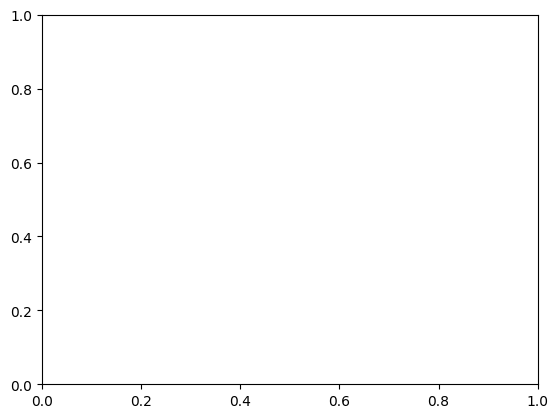

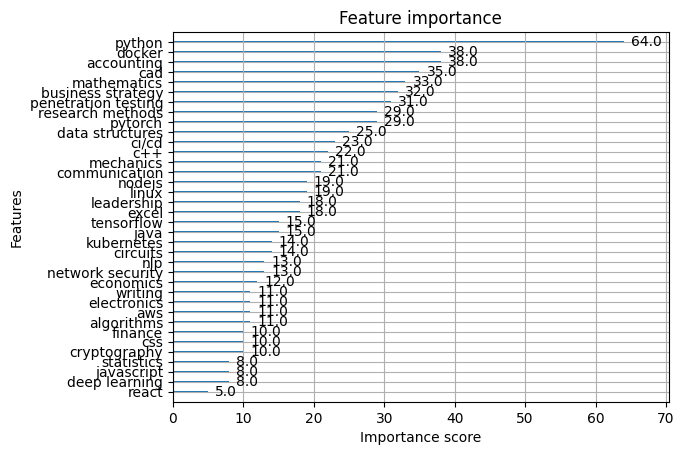

In [13]:
from xgboost import plot_tree
from xgboost import plot_importance
import matplotlib.pyplot as plt

try:
    plot_tree(model, num_trees=0)
except Exception as e:
    print(f"Error plotting tree: {e}. Plotting feature importance instead.")
    plot_importance(model)
plt.show()